In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Robert Swain

In [4]:
sample_size = 100
eligible_population = make_array(0.26, 0.74)

In [20]:
sample_proportions(sample_size, eligible_population)

array([ 0.21,  0.79])

In [22]:
def one_simulated_count():
    return sample_size * sample_proportions(sample_size, eligible_population).item(0)

In [31]:
one_simulated_count()

22.0

In [32]:
# Crushed ICE: create an array called counts and add 10,000 simulated counts to it
counts = make_array()
repetitions = 10000
for i in np.arange(repetitions):
    counts = np.append(counts, one_simulated_count())

In [33]:
counts

array([ 26.,  23.,  27., ...,  24.,  27.,  22.])

In [35]:
Table().with_column('Counts in a random sample', counts).sort(0)

Counts in a random sample
10
11
12
12
12
13
13
13
13
13


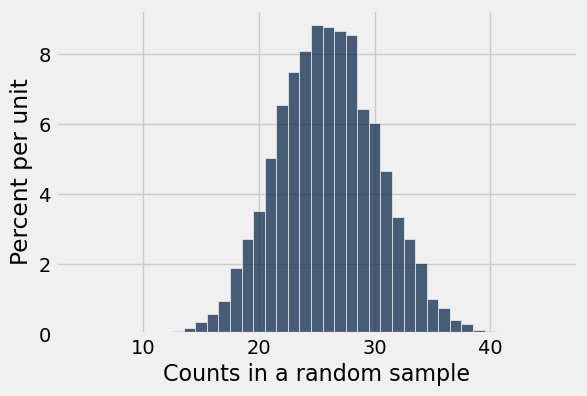

In [37]:
Table().with_column('Counts in a random sample', counts).hist(bins=np.arange(4.5, 45.6, 1))

In [39]:
np.count_nonzero(counts == 8)

0

In [40]:
np.count_nonzero(counts <= 8)

0

# Jury Selection in Alameda County

In [41]:
jury = Table().with_columns(
    'Ethnicity', make_array('Asian/PI', 'Black/AA', 'Caucasian', 'Hispanic', 'Other'),
    'Eligible', make_array(0.15, 0.18, 0.54, 0.12, 0.01),
    'Panels', make_array(0.26, 0.08, 0.54, 0.08, 0.04)
)
jury

Ethnicity,Eligible,Panels
Asian/PI,0.15,0.26
Black/AA,0.18,0.08
Caucasian,0.54,0.54
Hispanic,0.12,0.08
Other,0.01,0.04


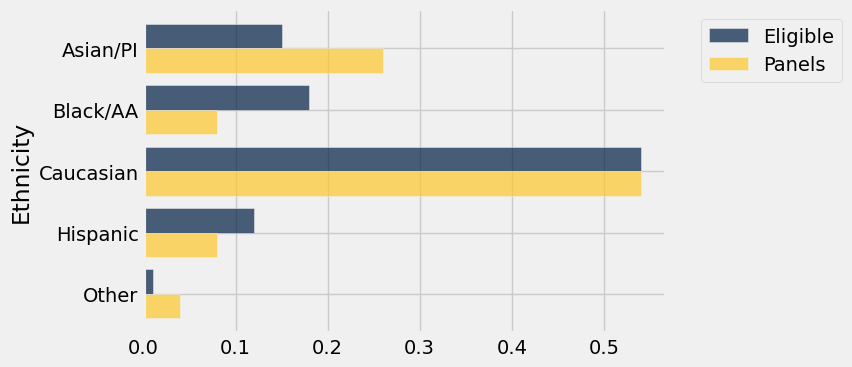

In [42]:
jury.barh('Ethnicity')

In [43]:
# Crushed ICE: There were 1,453 people on juries during the study.
# Using the proportions of eligible jurors and sample_proportions, simluate picking 1,453 jurors
jury.column('Eligible')

array([ 0.15,  0.18,  0.54,  0.12,  0.01])

In [50]:
model = jury.column('Eligible')
simulated = sample_proportions(1453, model)
simulated

array([ 0.13833448,  0.17894012,  0.56503785,  0.10736407,  0.01032347])

In [51]:
jury_with_simulated = jury.with_column('Simluated', simulated)
jury_with_simulated

Ethnicity,Eligible,Panels,Simluated
Asian/PI,0.15,0.26,0.138334
Black/AA,0.18,0.08,0.17894
Caucasian,0.54,0.54,0.565038
Hispanic,0.12,0.08,0.107364
Other,0.01,0.04,0.0103235


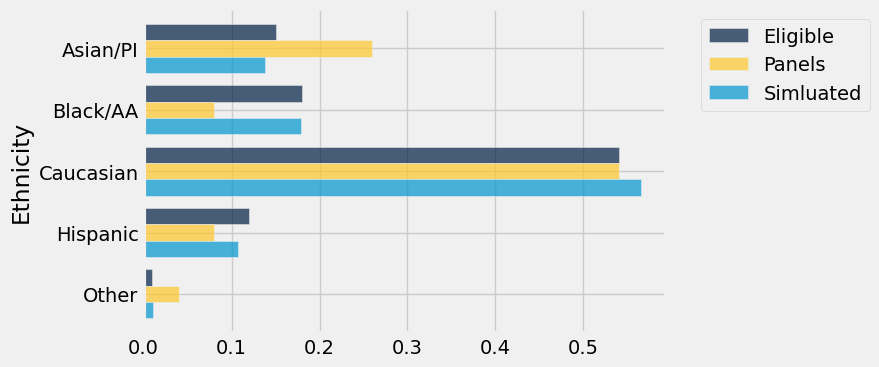

In [52]:
jury_with_simulated.barh('Ethnicity')

In [53]:
# There aren't just two things to compare! Goal: make *one number* to represent the differences
# We need a new statistic to measure the difference between the distributions!

In [56]:
diffs = jury.column('Panels') - jury.column('Eligible')
jury_with_difference = jury.with_column('Difference', diffs)
jury_with_difference

Ethnicity,Eligible,Panels,Difference
Asian/PI,0.15,0.26,0.11
Black/AA,0.18,0.08,-0.1
Caucasian,0.54,0.54,0
Hispanic,0.12,0.08,-0.04
Other,0.01,0.04,0.03


In [58]:
sum(jury_with_difference.where('Difference', are.above(0)).column('Difference'))

0.14000000000000001

In [63]:
sum(abs(jury_with_difference.column('Difference'))) / 2

0.14000000000000001

In [65]:
def tvd(dist1, dist2):
    return sum(abs(dist1 - dist2)) / 2

In [85]:
observed_tvd = tvd(jury.column('Panels'), jury.column('Eligible'))
observed_tvd

0.14000000000000001

In [86]:
tvd(sample_proportions(1453, model), jury.column('Eligible'))

0.014487267721954597

In [88]:
def simulated_tvd():
    return tvd(sample_proportions(1453, model), jury.column('Eligible'))

tvds = make_array()

# Crushed ICE: simulate 10,000 tvds into the tvds array
num_simulations = 10000
for i in np.arange(num_simulations):
    new_tvd = simulated_tvd()
    tvds = np.append(tvds, new_tvd)

In [89]:
len(tvds)

10000

In [90]:
tvds

array([ 0.01653131,  0.01549209,  0.01318651, ...,  0.0203097 ,
        0.01328975,  0.01434962])

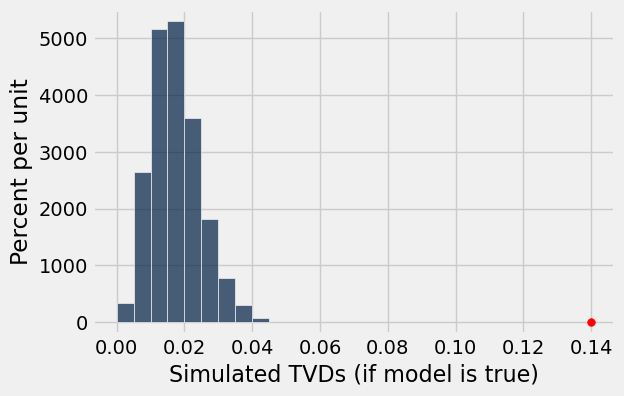

In [93]:
title = 'Simulated TVDs (if model is true)'
bins = np.arange(0, 0.05, 0.005)

Table().with_column(title, tvds).hist(bins=bins)

# Plotting the observed TVD--ignore this code!
plt.ylim(-2, 55)
plt.scatter(observed_tvd, 0, color='red', s=30);

In [94]:
np.count_nonzero(tvds >= 0.14)

0

# Mendel

In [2]:
705/929

0.7588805166846071

In [7]:
observed_statistic = abs(100 * (705 / 929) - 75)
observed_statistic

0.8880516684607045

In [8]:
# Crushed ICE: use Mendel's model (75% purple, 25% white) to simulate a garden of 929 pea plants,
# and extract the proportion that were purple
# Hint: use sample_proportions

In [11]:
mendel_proportions = make_array(0.75, 0.25)

sample_proportions(929, mendel_proportions)

array([ 0.75780409,  0.24219591])

In [20]:
sample_proportion_purple = sample_proportions(929, mendel_proportions).item(0)
abs(100 * sample_proportion_purple - 75)

1.7491926803014053

In [21]:
# Crushed ICE: make a function called one_simulated_distance to run a single simulation
# and calculate the distance from Mendel's model
def one_simulated_distance():
    sample_proportion_purple = sample_proportions(929, mendel_proportions).item(0)
    return abs(100 * sample_proportion_purple - 75)

In [25]:
one_simulated_distance()

1.8568353067814911

In [26]:
repetitions = 10000
distances = make_array()
for i in np.arange(repetitions):
    distances = np.append(distances, one_simulated_distance())

In [27]:
distances

array([ 0.45748116,  1.85683531,  0.34983854, ...,  1.04951561,
        0.29601722,  0.40365985])

In [29]:
dists = Table().with_column(
    'Distance between Sample % and 75%', distances
)
dists

Distance between Sample % and 75%
0.457481
1.85684
0.349839
0.080732
0.457481
2.87944
3.68676
1.37244
1.10334
2.61033


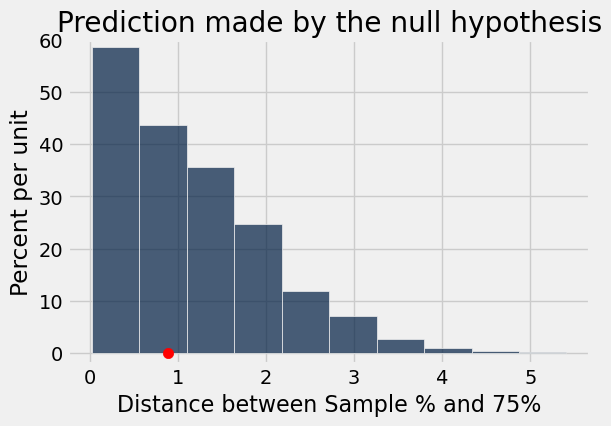

In [32]:
dists.hist()
plt.title('Prediction made by the null hypothesis')

plt.ylim(-0.02, 0.6)
plt.scatter(observed_statistic, 0, color='red', s=55);

In [36]:
np.count_nonzero(distances >= observed_statistic) / repetitions

0.5515

In [37]:
# ^ a p-value

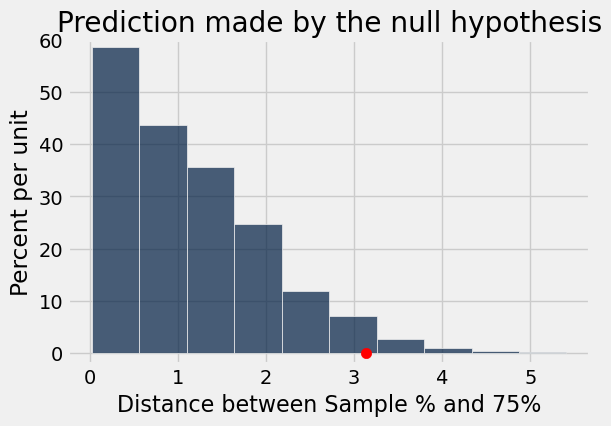

In [38]:
different_observed_statistic = 3.14

dists.hist()
plt.title('Prediction made by the null hypothesis')

plt.ylim(-0.02, 0.6)
plt.scatter(different_observed_statistic, 0, color='red', s=55);

In [39]:
np.count_nonzero(distances >= different_observed_statistic) / repetitions

0.0273

# Midterm Scores

In [40]:
scores = Table.read_table('data/scores_by_section.csv')
scores

Section,Midterm
1,22
2,12
2,23
2,14
1,20
3,25
4,19
1,24
5,8
6,14


In [44]:
# Crushed ICE: get the average midterm scores by section
scores.group('Section', np.average).show()

Section,Midterm average
1,15.5938
2,15.125
3,13.6667
4,14.7667
5,17.4545
6,15.0312
7,16.625
8,16.3103
9,14.5667
10,15.2353


In [46]:
scores.group('Section').show()

Section,count
1,32
2,32
3,27
4,30
5,33
6,32
7,24
8,29
9,30
10,34


In [48]:
section_3_average = scores.group('Section', np.average).column('Midterm average').item(2)
section_3_size = scores.group('Section').column('count').item(2)

In [51]:
# Crushed ICE: simulate a section with the same size as Section 3 by picking random students,
# and get the average score.
# Don't allow any students to be included multiple times!
random_section = scores.sample(section_3_size, with_replacement=False)
random_section

Section,Midterm
4,7
1,8
6,14
6,10
2,21
4,13
3,23
8,17
2,17
6,10


In [53]:
np.average(random_section.column('Midterm'))

13.962962962962964

In [62]:
np.average(scores.sample(section_3_size, with_replacement=False).column('Midterm'))

15.037037037037036

In [63]:
def one_simulated_average():
    return np.average(scores.sample(section_3_size, with_replacement=False).column('Midterm'))

one_simulated_average()

15.148148148148149